### Project : chronic liver disease
##### Developed by:madhu, Nayana, srushti, sushma



This cell imports all required libraries for data analysis, visualization, preprocessing, feature extraction, and machine learning.

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:

csv_path = Path("dataset/Liver_Patient_Dataset_LPD_train.csv")
df = pd.read_csv(csv_path,encoding="ISO-8859-1")

In [7]:

print(df["Gender of the patient"].value_counts())
print("---------------------------------------------")
print(df.isnull().sum())
print("---------------------------------------------")
print(df.shape)

Gender of the patient
Male      21986
Female     7803
Name: count, dtype: int64
---------------------------------------------
Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64
---------------------------------------------
(30691, 11)


In [8]:
df.head(50)

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
5,46.0,Male,1.8,0.7,208.0,19.0,14.0,7.6,4.4,1.30,1
6,26.0,Female,0.9,0.2,154.0,NaN,12.0,7.0,3.5,1.00,1
7,29.0,Female,0.9,0.3,202.0,14.0,11.0,6.7,3.6,1.10,1
8,17.0,Male,0.9,0.3,202.0,22.0,19.0,7.4,4.1,1.20,2
9,55.0,Male,0.7,0.2,290.0,53.0,58.0,6.8,3.4,1.00,1


In [9]:
df.describe()

,Age of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
count,30689.000000,30043.000000,30130.000000,29895.000000,30153.000000,30229.000000,30228.000000,30197.000000,30132.000000,30691.000000
mean,44.107205,3.370319,1.528042,289.075364,81.488641,111.469979,6.480237,3.130142,0.943467,1.285882
std,15.981043,6.255522,2.869592,238.537589,182.158850,280.851078,1.081980,0.792281,0.323164,0.451841
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.800000,0.200000,175.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,55.000000,2.700000,1.300000,298.000000,62.000000,88.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


<Axes: xlabel='\xa0ALB Albumin', ylabel='Count'>

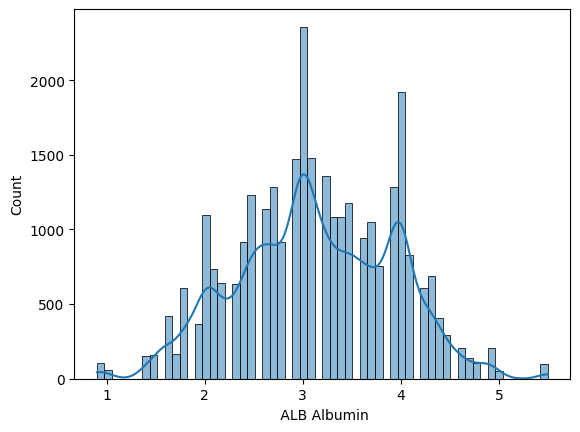

In [10]:
sns.histplot(df["\xa0ALB Albumin"], kde=True)

In [11]:
print(df.columns.to_list())

['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


<Axes: xlabel='\xa0Alkphos Alkaline Phosphotase', ylabel='Total Protiens'>

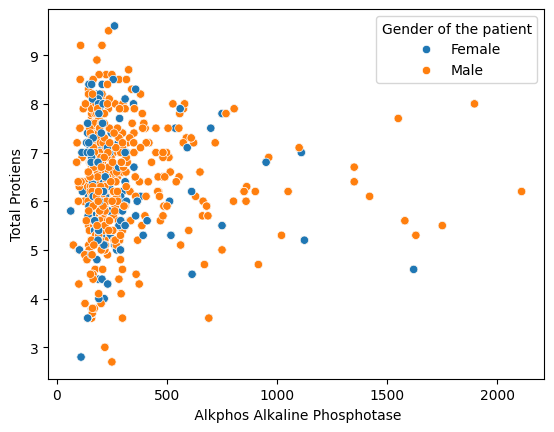

In [12]:
sns.scatterplot(x=df["\xa0Alkphos Alkaline Phosphotase"],y=df["Total Protiens"],hue=df["Gender of the patient"])

In [13]:
pd.crosstab(columns=df["Gender of the patient"], index=df["Age of the patient"])

Gender of the patient,Female,Male
Age of the patient,,
4.0,17,116
6.0,3,22
7.0,19,71
8.0,15,5
10.0,46,17
...,...,...
84.0,9,6
85.0,19,9
86.0,5,22


<Axes: ylabel='Age of the patient'>

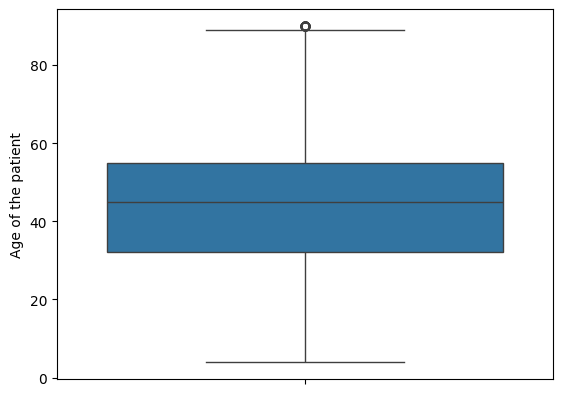

In [14]:
sns.boxplot(df["Age of the patient"])

<Axes: ylabel='Total Bilirubin'>

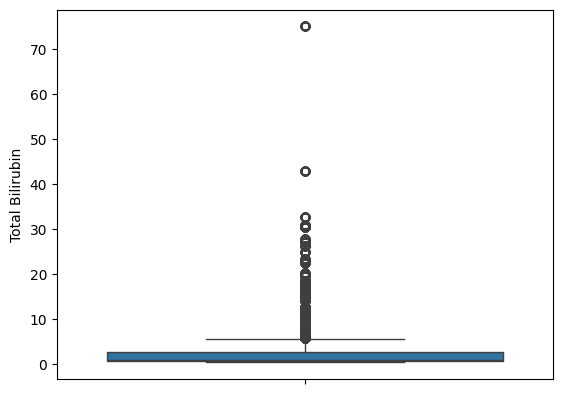

In [15]:
sns.boxplot(df["Total Bilirubin"])

<Axes: ylabel='Total Protiens'>

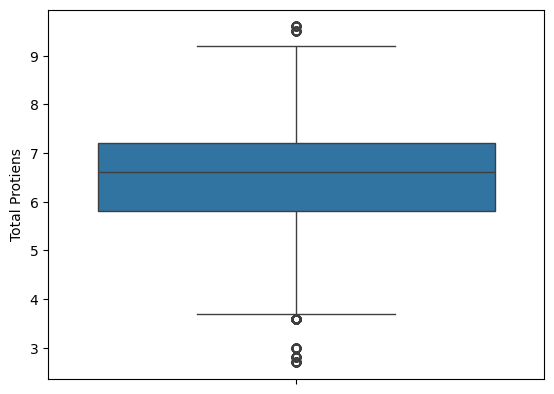

In [16]:
sns.boxplot(df["Total Protiens"])

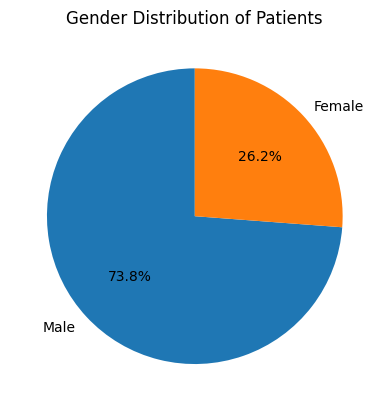

In [17]:
gender_counts = df["Gender of the patient"].value_counts()
plt.pie(
    gender_counts.values, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90
)
plt.title("Gender Distribution of Patients")
plt.show()

<Axes: >

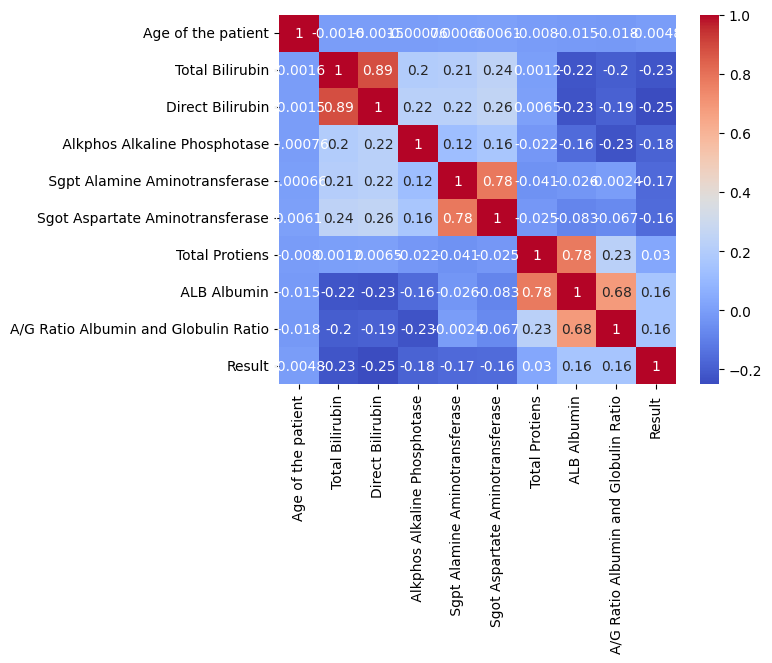

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

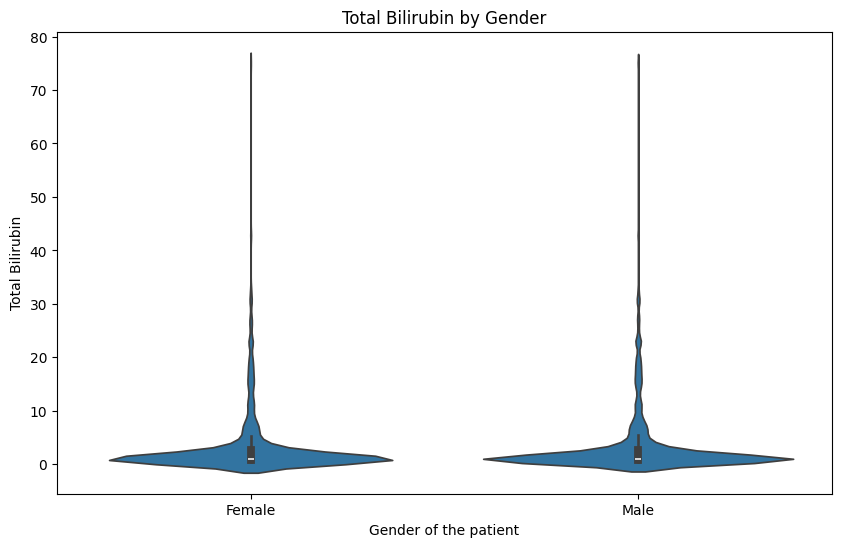

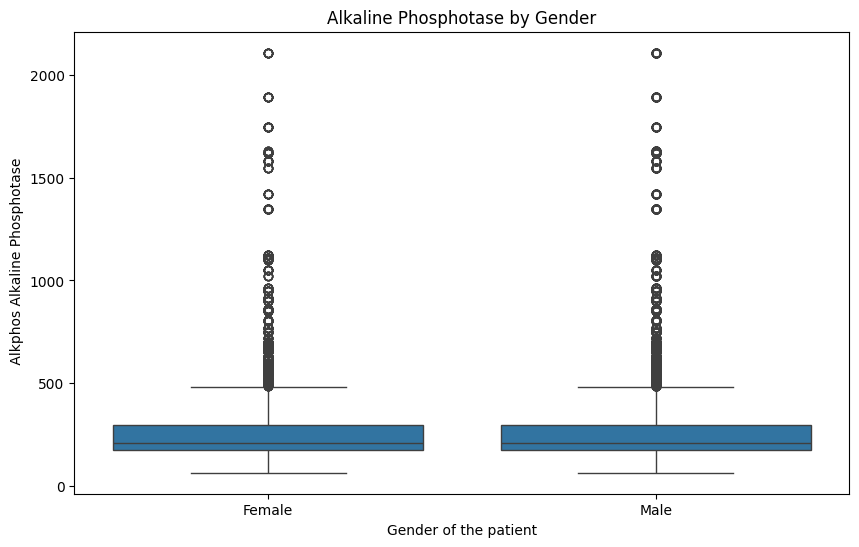

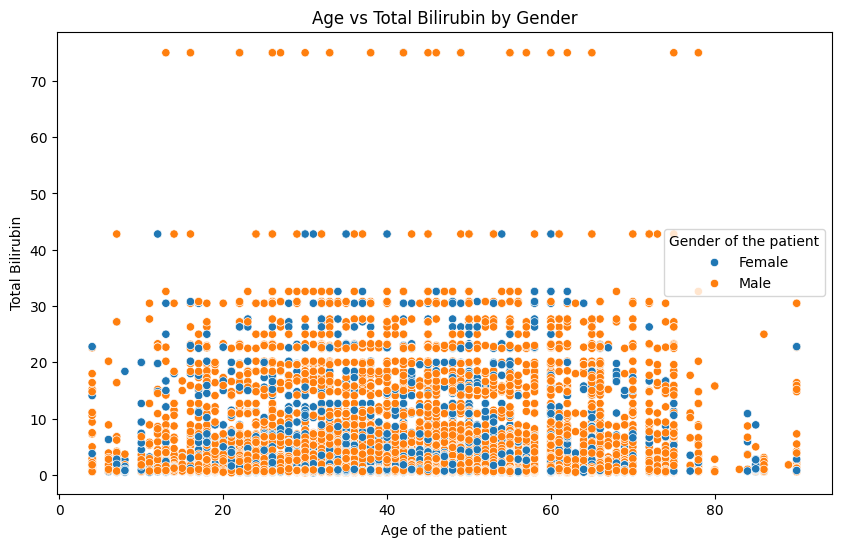

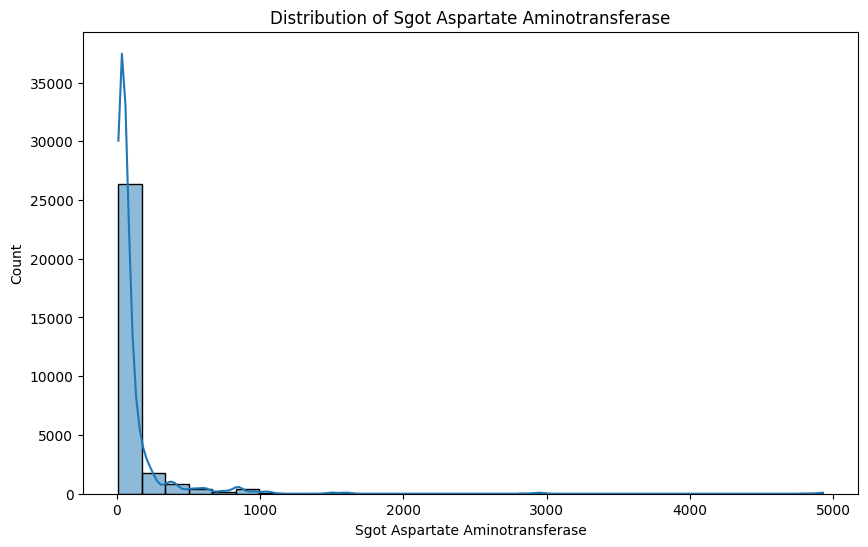

In [19]:
# Additional Graphs for Data Exploration
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Gender of the patient'], y=df['Total Bilirubin'])
plt.title('Total Bilirubin by Gender')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=df['Gender of the patient'], y=df['\xa0Alkphos Alkaline Phosphotase'])
plt.title('Alkaline Phosphotase by Gender')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Age of the patient'], y=df['Total Bilirubin'], hue=df['Gender of the patient'])
plt.title('Age vs Total Bilirubin by Gender')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df['Sgot Aspartate Aminotransferase'], bins=30, kde=True)
plt.title('Distribution of Sgot Aspartate Aminotransferase')
plt.show()

In [20]:
# Clean column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Encode categorical variables
X['Gender of the patient'] = X['Gender of the patient'].map({'Male': 1, 'Female': 0})

# Check for missing values and handle them
print("Missing values before imputation:")
print(X.isnull().sum())

# Fill missing values with median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("\nMissing values after imputation:")
print(X.isnull().sum())

print(f"\nFinal shape - X: {X.shape}, y: {y.shape}")


Missing values before imputation:
Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
Alkphos Alkaline Phosphotase            796
Sgpt Alamine Aminotransferase           538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
ALB Albumin                             494
A/G Ratio Albumin and Globulin Ratio    559
dtype: int64

Missing values after imputation:
Age of the patient                      0
Gender of the patient                   0
Total Bilirubin                         0
Direct Bilirubin                        0
Alkphos Alkaline Phosphotase            0
Sgpt Alamine Aminotransferase           0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
ALB Albumin                             0
A/G Ratio Albumin and Globulin Ratio    0
dtype: int64

Final shape - X: (30691, 10), y: (30691,)


In [21]:
 # Define custom projection-based statistical feature extractor
class ProjectionBasedFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Integrated Projection-Based Statistical Feature Extraction
    Computes statistical moments and projections of features
    """
    def __init__(self, n_projections=5):
        self.n_projections = n_projections
        self.projection_matrix_ = None
        
    def fit(self, X, y=None):
        # Create random projections
        np.random.seed(42)
        self.projection_matrix_ = np.random.randn(X.shape[1], self.n_projections)
        # Normalize projections
        self.projection_matrix_ = self.projection_matrix_ / np.linalg.norm(self.projection_matrix_, axis=0)
        return self
    
    def transform(self, X):
        X_array = np.array(X)
        
        # Original features
        features = [X_array]
        
        # Statistical moments (mean, std, skewness, kurtosis approximation)
        # Sliding window statistics
        window_size = 3
        if X_array.shape[1] >= window_size:
            # Local mean
            local_mean = np.array([X_array[:, i:i+window_size].mean(axis=1) 
                                   for i in range(X_array.shape[1]-window_size+1)]).T
            features.append(local_mean)
            
            # Local variance
            local_var = np.array([X_array[:, i:i+window_size].var(axis=1) 
                                  for i in range(X_array.shape[1]-window_size+1)]).T
            features.append(local_var)
        
        # Projection-based features
        projections = X_array @ self.projection_matrix_
        features.append(projections)
        
        # Statistical aggregates
        stats_features = np.column_stack([
            X_array.mean(axis=1),  # Mean of all features
            X_array.std(axis=1),   # Std of all features
            X_array.max(axis=1),   # Max of all features
            X_array.min(axis=1),   # Min of all features
            (X_array.max(axis=1) - X_array.min(axis=1))  # Range
        ])
        features.append(stats_features)
        
        # Combine all features
        X_transformed = np.hstack(features)
        return X_transformed

# Test the custom transformer
extractor = ProjectionBasedFeatureExtractor(n_projections=5)
X_extracted = extractor.fit_transform(X)
print(f"Original features shape: {X.shape}")
print(f"Extracted features shape: {X_extracted.shape}")
print(f"New features: {X_extracted.shape[1]} (from {X.shape[1]})")


Original features shape: (30691, 10)
Extracted features shape: (30691, 36)
New features: 36 (from 10)


In [22]:
# Create preprocessing pipeline with feature extraction
preprocessing_pipeline = Pipeline([
    ('feature_extractor', ProjectionBasedFeatureExtractor(n_projections=5)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95))  # Keep 95% of variance
])

# Fit and transform the data
X_processed = preprocessing_pipeline.fit_transform(X)
print(f"Processed features shape: {X_processed.shape}")
print(f"Features after preprocessing: {X_processed.shape[1]}")


Processed features shape: (30691, 8)
Features after preprocessing: 8


In [23]:
# Define models for training
models = {
    'Logistic Regression': LogisticRegression(max_iter=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, average='weighted'),
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_results_summary = {}

print("="*80)
print("CROSS-VALIDATION RESULTS FOR ALL MODELS")
print("="*80)

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name}")
    print(f"{'='*80}")
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_processed, y, 
        cv=skf, 
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Store results
    cv_results_summary[model_name] = cv_results
    
    # Print detailed results
    for metric in scoring.keys():
        train_scores = cv_results[f'train_{metric}']
        test_scores = cv_results[f'test_{metric}']
        
        print(f"\n{metric.upper()}:")
        print(f"  Train scores: {train_scores}")
        print(f"  Test scores:  {test_scores}")
        print(f"  Mean Train:   {train_scores.mean():.4f} (+/- {train_scores.std():.4f})")
        print(f"  Mean Test:    {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")

print("\n" + "="*80)


CROSS-VALIDATION RESULTS FOR ALL MODELS

Model: Logistic Regression

ACCURACY:
  Train scores: [0.71444282 0.71677595 0.71921965 0.71742761 0.71661304]
  Test scores:  [0.71949829 0.71766048 0.71146953 0.71521668 0.7161942 ]
  Mean Train:   0.7169 (+/- 0.0015)
  Mean Test:    0.7160 (+/- 0.0027)

F1:
  Train scores: [0.65943491 0.6651821  0.66801846 0.66297421 0.66436646]
  Test scores:  [0.66223617 0.664489   0.65766731 0.66432147 0.66606944]
  Mean Train:   0.6640 (+/- 0.0028)
  Mean Test:    0.6630 (+/- 0.0029)

ROC_AUC:
  Train scores: [0.54990867 0.55607788 0.5589713  0.55353011 0.55513847]
  Test scores:  [0.55262655 0.55506665 0.54822595 0.55529113 0.55717136]
  Mean Train:   0.5547 (+/- 0.0030)
  Mean Test:    0.5537 (+/- 0.0031)

BALANCED_ACCURACY:
  Train scores: [0.54990867 0.55607788 0.5589713  0.55353011 0.55513847]
  Test scores:  [0.55262655 0.55506665 0.54822595 0.55529113 0.55717136]
  Mean Train:   0.5547 (+/- 0.0030)
  Mean Test:    0.5537 (+/- 0.0031)

Model: Suppor

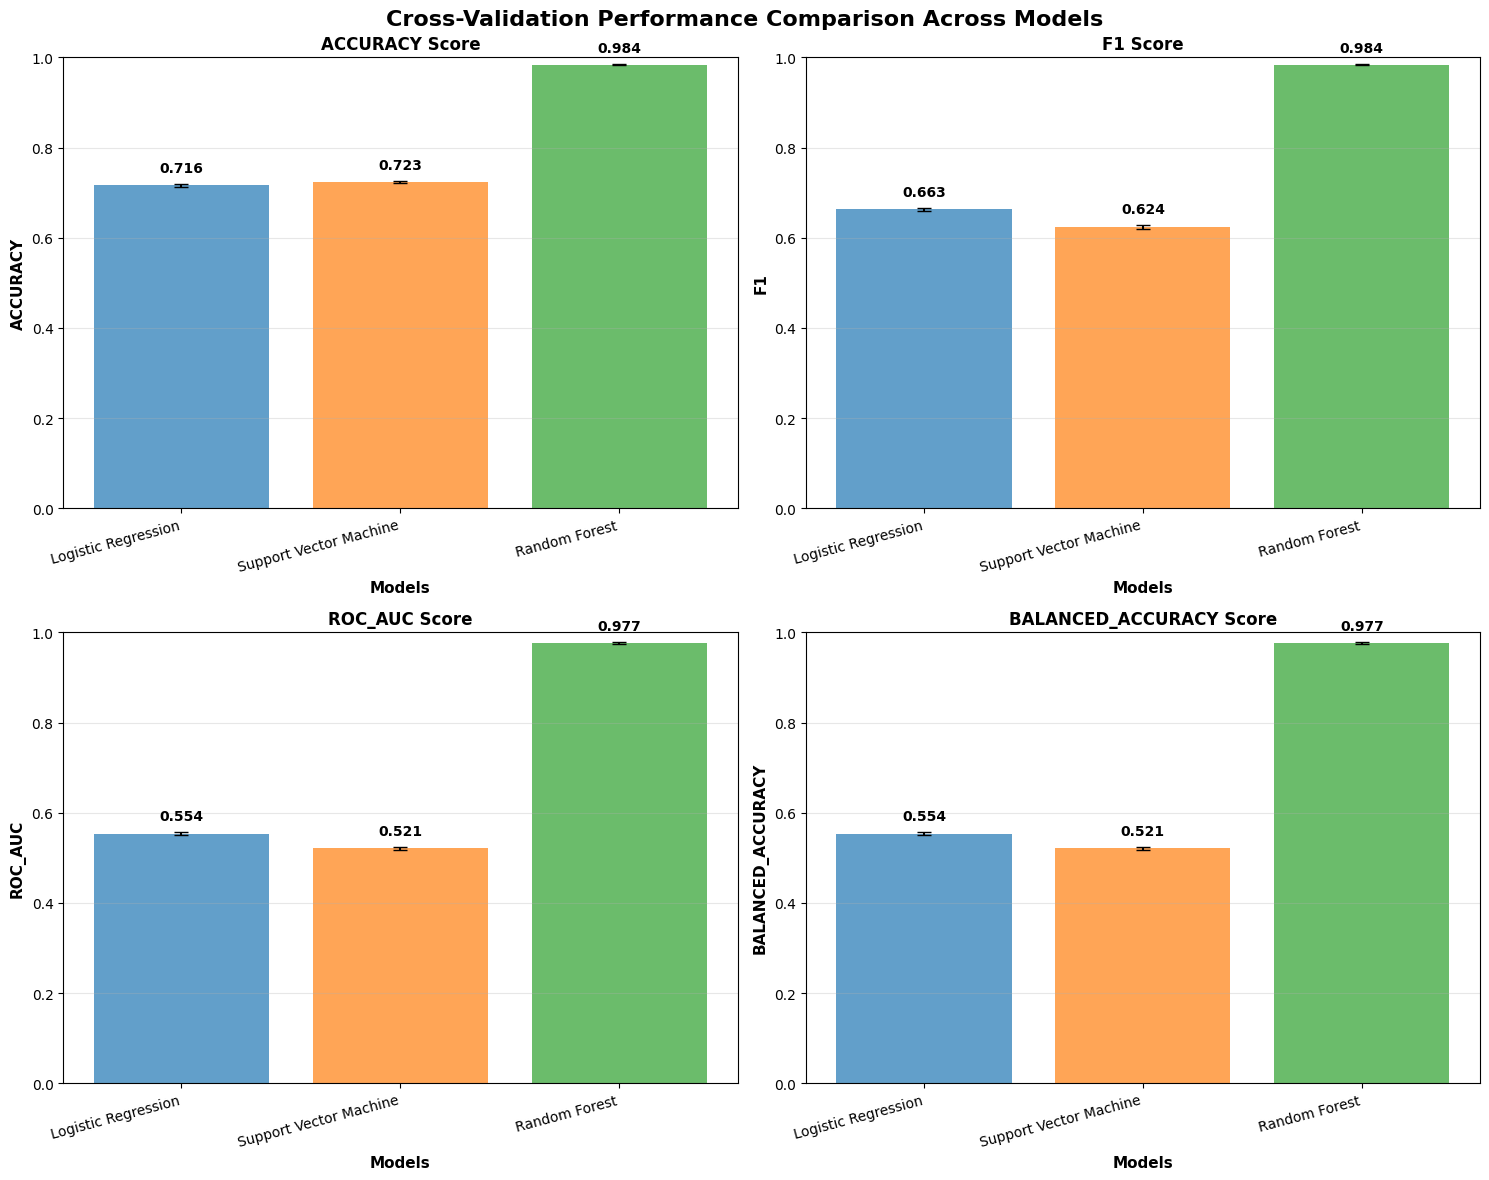

In [24]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Cross-Validation Performance Comparison Across Models', fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'f1', 'roc_auc', 'balanced_accuracy']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for plotting
    model_names = []
    test_means = []
    test_stds = []
    
    for model_name in models.keys():
        model_names.append(model_name)
        test_scores = cv_results_summary[model_name][f'test_{metric}']
        test_means.append(test_scores.mean())
        test_stds.append(test_scores.std())
    
    # Create bar plot
    x_pos = np.arange(len(model_names))
    bars = ax.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    
    ax.set_xlabel('Models', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.upper(), fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.upper()} Score', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        ax.text(i, mean + std + 0.02, f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [25]:
# Create comprehensive summary table
summary_data = []

for model_name in models.keys():
    row = {'Model': model_name}
    
    for metric in scoring.keys():
        test_scores = cv_results_summary[model_name][f'test_{metric}']
        row[f'{metric}_mean'] = test_scores.mean()
        row[f'{metric}_std'] = test_scores.std()
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display summary
print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY (5-FOLD Cross-Validation)")
print("="*100)

for metric in scoring.keys():
    print(f"\n{metric.upper()} Scores:")
    print("-" * 100)
    for _, row in summary_df.iterrows():
        mean = row[f'{metric}_mean']
        std = row[f'{metric}_std']
        print(f"  {row['Model']:30s}: {mean:.4f} ± {std:.4f}")

# Find best models
print("\n" + "="*100)
print("BEST MODELS BY METRIC")
print("="*100)

for metric in scoring.keys():
    best_idx = summary_df[f'{metric}_mean'].idxmax()
    best_model = summary_df.loc[best_idx, 'Model']
    best_score = summary_df.loc[best_idx, f'{metric}_mean']
    print(f"{metric.upper():20s}: {best_model:30s} ({best_score:.4f})")

print("\n" + "="*100)



MODEL PERFORMANCE SUMMARY (5-FOLD Cross-Validation)

ACCURACY Scores:
----------------------------------------------------------------------------------------------------
  Logistic Regression           : 0.7160 ± 0.0027
  Support Vector Machine        : 0.7231 ± 0.0016
  Random Forest                 : 0.9838 ± 0.0017

F1 Scores:
----------------------------------------------------------------------------------------------------
  Logistic Regression           : 0.6630 ± 0.0029
  Support Vector Machine        : 0.6244 ± 0.0044
  Random Forest                 : 0.9837 ± 0.0017

ROC_AUC Scores:
----------------------------------------------------------------------------------------------------
  Logistic Regression           : 0.5537 ± 0.0031
  Support Vector Machine        : 0.5215 ± 0.0034
  Random Forest                 : 0.9770 ± 0.0026

BALANCED_ACCURACY Scores:
----------------------------------------------------------------------------------------------------
  Logistic Regressi


TOP 10 MOST IMPORTANT FEATURES (from Random Forest)
Feature  Importance
   PC_1    0.197405
   PC_8    0.188624
   PC_7    0.158489
   PC_2    0.146446
   PC_6    0.099332
   PC_3    0.094470
   PC_4    0.076726
   PC_5    0.038506


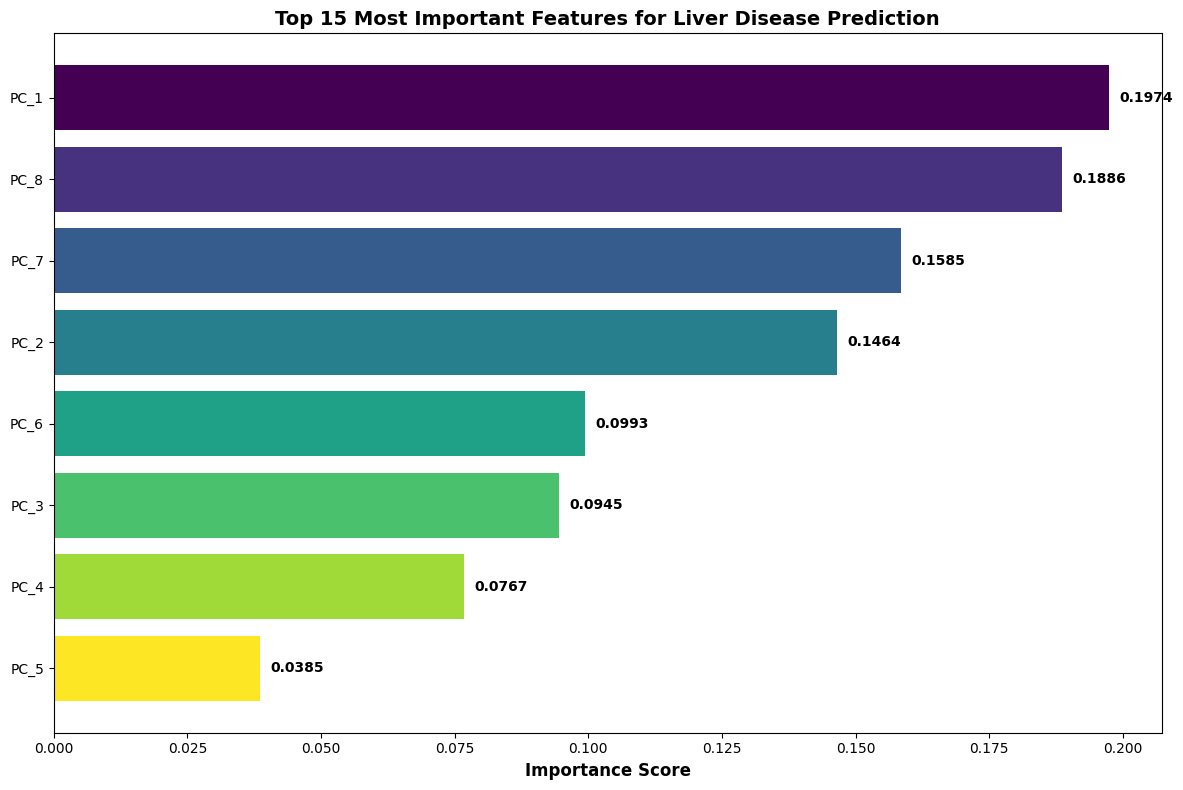

In [26]:
# Train Random Forest on full preprocessed data for feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_processed, y)

# Get feature importances
feature_importance = rf_model.feature_importances_

# Get PCA feature names
pca_model = preprocessing_pipeline.named_steps['pca']
n_features = pca_model.n_components_

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'Feature': [f'PC_{i+1}' for i in range(len(feature_importance))],
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES (from Random Forest)")
print("="*60)
print(importance_df.head(10).to_string(index=False))
print("="*60)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))

top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)

colors = plt.cm.viridis(np.linspace(0, 1, top_n))
bars = ax.barh(range(top_n), top_features['Importance'].values, color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Features for Liver Disease Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['Importance'] + 0.002, i, f"{row['Importance']:.4f}", 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [23]:
import pandas as pd

data = pd.read_csv(r"D:\LiverDisease\dataset\Liver_Patient_Dataset_LPD_train.csv", encoding='latin1')
print(data.head())          # show first 5 rows
print(data.columns.tolist())  # show all column names

   Age of the patient Gender of the patient  Total Bilirubin  \
0                65.0                Female              0.7   
1                62.0                  Male             10.9   
2                62.0                  Male              7.3   
3                58.0                  Male              1.0   
4                72.0                  Male              3.9   

   Direct Bilirubin   Alkphos Alkaline Phosphotase  \
0               0.1                          187.0   
1               5.5                          699.0   
2               4.1                          490.0   
3               0.4                          182.0   
4               2.0                          195.0   

    Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                            16.0                             18.0   
1                            64.0                            100.0   
2                            60.0                             68.0   
3         

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Step 1: Load and clean dataset
# -----------------------------
data = pd.read_csv(r"D:\LiverDisease\dataset\Liver_Patient_Dataset_LPD_train.csv", encoding='latin1')

# Clean column names (strip and remove non-breaking spaces)
data.columns = data.columns.str.strip().str.replace('\xa0', '', regex=True)

# Optional: quick look at missing values
print("Missing values per column:\n", data.isna().sum())

# -----------------------------
# Step 2: Define target and drop rows with missing target
# -----------------------------
TARGET_COL = "Result"
if TARGET_COL not in data.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available columns: {data.columns.tolist()}")

# Drop rows with missing target
data = data.dropna(subset=[TARGET_COL])

# Separate features/target
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

# If y is not numeric, make it numeric (optional)
y = pd.to_numeric(y, errors='coerce')
if y.isna().any():
    # If converting introduces NaNs, drop them
    not_null_idx = ~y.isna()
    X = X.loc[not_null_idx]
    y = y.loc[not_null_idx]

# -----------------------------
# Step 3: Identify column types
# -----------------------------
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# -----------------------------
# Step 4: Preprocessing (impute -> encode -> scale)
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# -----------------------------
# Step 5: Build pipeline and tune KNN
# -----------------------------
knn = KNeighborsClassifier()

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knn", knn)
])

param_grid = {
    "knn__n_neighbors": np.arange(3, 21),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

# -----------------------------
# Step 6: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Step 7: Fit and evaluate
# -----------------------------
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Missing values per column:
 Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
Alkphos Alkaline Phosphotase            796
Sgpt Alamine Aminotransferase           538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
ALB Albumin                             494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64
Numeric columns: ['Age of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio']
Categorical columns: ['Gender of the patient']
Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': np.int64(4), 'knn__weights': 'distance'}
Best CV accuracy: 0.9790647538403542

Confusion Matrix:
 [[4343   41]

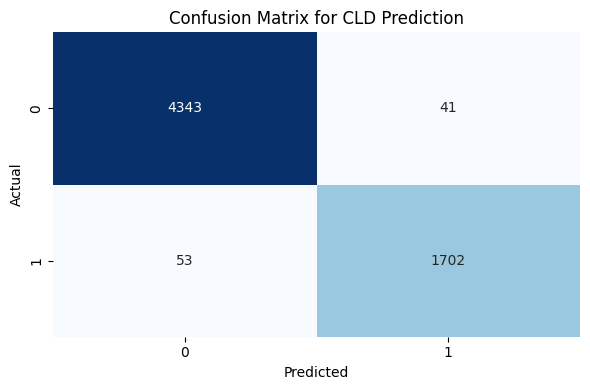

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label axes and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for CLD Prediction')
plt.tight_layout()
plt.show()

<Axes: >

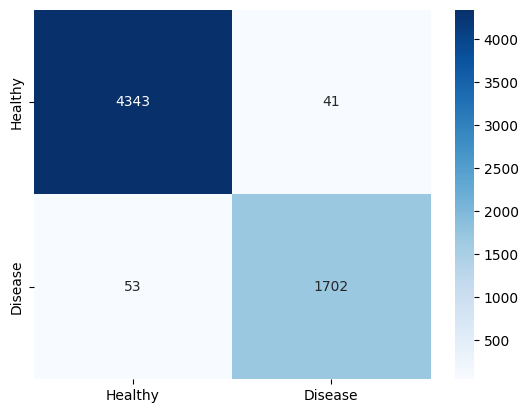

In [27]:
labels = ["Healthy", "Disease"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

In [33]:
print("Actual label counts:")
print(y.value_counts())

Actual label counts:
Result
1    21917
2     8774
Name: count, dtype: int64


In [42]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import pandas as pd

# ---- Fix Missing Values ----
imputer = SimpleImputer(strategy='mean')
X_raw = imputer.fit_transform(X_raw)

# ---- PCA ----
pca = PCA(n_components=5)
pca_features = pca.fit_transform(X_raw)

# ---- Final Output ----
X = pd.DataFrame({
    'mean': mean_feat,
    'std': std_feat,
    'skew': skew_feat,
    'kurt': kurt_feat
})

print("Fixed successfully!")


Fixed successfully!


c:\Users\91962\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Gender of the patient']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [44]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import pandas as pd

# ---- Fix Missing Values ----
imputer = SimpleImputer(strategy='mean')
X_raw = imputer.fit_transform(X_raw)

# ---- PCA ----
pca = PCA(n_components=5)
pca_features = pca.fit_transform(X_raw)

# ---- Feature Stats ----
X = pd.DataFrame({
    'mean': mean_feat,
    'std': std_feat,
    'skew': skew_feat,
    'kurt': kurt_feat
})

print("✅ PCA completed successfully — No NaN error!")


✅ PCA completed successfully — No NaN error!


c:\Users\91962\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Gender of the patient']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
